# Check tile processing status

Live view of fleet progress, derived entirely from the Icechunk commit history via
[`global_snowmelt_runoff_onset/status.py`](../global_snowmelt_runoff_onset/status.py).
Every tile×water-year and every tile-composite refresh is one commit carrying structured
metadata (status, stats, duration, provenance); **failures never commit, so absence == not
done**. Everything here is read-only and safe to run at any time — including while a fleet
run is actively writing. Re-run the cells to refresh.

Each status call below walks the branch ancestry once, so expect a short wait per call on a
long history.

In [19]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from global_snowmelt_runoff_onset.config import Config
from global_snowmelt_runoff_onset import status

In [20]:
config = Config('config/global_config_v10.txt')
repo = config.open_output_repo()

SAS token is valid until 2026-08-26 19:52 UTC (523.0 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v10
version = v10
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 84.048
bbox_bottom = -63.4074
expected_grid_shape = 204800, 499998
expected_tile_grid = 100, 245
wy_start = 2015
wy_end = 2025
trailing_buffer_days = 120
low_backscatter_threshold = 0.001
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow_v10.geojson
global_runoff_icechunk_azure_prefix = snowmelt/snowmelt_runoff_onset/global_runoff_onset_v10
inner_chunk_dim = 256
snow_phenology_zarr_store_azure_path = snowmelt/modis_sn

## Overall progress

`status.get_tile_status_gdf` joins the static tile registry with the commit history: one row
per registry tile with `to_process == True`, one `wy_<year>` column per water year
(`data` / `empty` / `missing` / `ineligible` — the tile hemisphere's season hasn't elapsed
yet), a `composites` column (`data` / `empty` / `missing` / `stale`), and a rolled-up
`tile_status` (`complete` / `partial` / `unprocessed`). `complete` counts only currently
*eligible* years.

In [21]:
tiles_gdf = status.get_tile_status_gdf(config, repo=repo)
wy_cols = [c for c in tiles_gdf.columns if c.startswith('wy_')]
tiles_gdf.head(3)

,row,col,percent_valid_snow_pixels,n_vv_items,n_vh_items,n_hh_items,n_hv_items,n_items_total,first_vv_date,s1_probe_date,...,wy_2020,wy_2021,wy_2022,wy_2023,wy_2024,wy_2025,composites,n_years_done,n_years_eligible,tile_status
4072,16,152,100.0,299,299,0,0,299,2015-04-24,2026-08-04,...,missing,missing,missing,missing,missing,missing,missing,0,11,unprocessed
3965,16,45,100.0,1502,1448,0,0,1502,2015-03-14,2026-08-04,...,missing,missing,missing,missing,missing,missing,missing,0,11,unprocessed
3745,15,70,100.0,370,370,3,3,373,2015-03-26,2026-08-04,...,missing,missing,missing,missing,missing,missing,missing,0,11,unprocessed


In [22]:
n_eligible = int((tiles_gdf[wy_cols] != 'ineligible').sum().sum())
n_done = int(tiles_gdf[wy_cols].isin(['data', 'empty']).sum().sum())

print(f'registry tiles: {len(tiles_gdf):,}')
for tile_status, count in tiles_gdf.tile_status.value_counts().items():
    print(f'  {tile_status:<12}: {count:>6,} ({count / len(tiles_gdf):.1%})')
print(f'tile-years    : {n_done:,} / {n_eligible:,} eligible committed ({n_done / max(n_eligible, 1):.1%})')
print('composites    : ' + ', '.join(f'{k}: {v:,}' for k, v in tiles_gdf.composites.value_counts().items()))

registry tiles: 4,227
  unprocessed :  4,054 (95.9%)
  complete    :    137 (3.2%)
  partial     :     36 (0.9%)
tile-years    : 1,697 / 46,497 eligible committed (3.6%)
composites    : missing: 4,090, data: 137


Per-water-year breakdown across all registry tiles:

In [23]:
wy_breakdown = (
    tiles_gdf[wy_cols]
    .apply(pd.Series.value_counts)
    .T.fillna(0).astype(int)
    .reindex(columns=['data', 'empty', 'missing', 'ineligible'], fill_value=0)
)
wy_eligible_counts = wy_breakdown[['data', 'empty', 'missing']].sum(axis=1)
wy_breakdown['pct_done_of_eligible'] = np.where(
    wy_eligible_counts > 0,
    (wy_breakdown['data'] + wy_breakdown['empty']) / wy_eligible_counts * 100,
    np.nan,
).round(1)
wy_breakdown.index = [c.removeprefix('wy_') for c in wy_breakdown.index]
wy_breakdown

,data,empty,missing,ineligible,pct_done_of_eligible
2015,173,0,4054,0,4.1
2016,169,2,4056,0,4.0
2017,168,0,4059,0,4.0
2018,166,0,4061,0,3.9
2019,159,0,4068,0,3.8
2020,152,0,4075,0,3.6
2021,147,0,4080,0,3.5
2022,144,0,4083,0,3.4
2023,139,2,4086,0,3.3
2024,137,2,4088,0,3.3


## Commit records — all processing metadata

`status.get_commit_records` returns one row per pipeline commit (newest first), including the
per-commit `stats` dict (valid pixels, scene/orbit counts, median temporal resolution),
`duration_s`, `missing_assets` (scenes dropped because their blobs 404'd), and the full
compute-platform `provenance` (GitHub Actions run/runner, JupyterHub user, or hostname).

In [24]:
commits_df = status.get_commit_records(repo)
commits_df['written_at'] = pd.to_datetime(commits_df['written_at'], utc=True)
commits_df['water_year'] = commits_df['water_year'].astype('Int64')
year_commits = commits_df[commits_df.kind == status.KIND_TILE_YEAR]

print(f'{len(commits_df):,} pipeline commits: {len(year_commits):,} tile-year, '
      f'{(commits_df.kind == status.KIND_TILE_COMPOSITE).sum():,} composite')
commits_df.head()

1,834 pipeline commits: 1,697 tile-year, 137 composite


,ancestry_index,snapshot_id,written_at,kind,row,col,water_year,status,empty_reason,config_version,stats,duration_s,missing_assets,provenance
0,0,YMYXSJN534F5B0JX83JG,2026-08-05 00:54:14.619095+00:00,tile_year,27,44,2018,data,NaN,v10,"{'mb_s_effective': 16.0, 'valid_px': 868816, '...",51.4,None,"{'run_attempt': '1', 'platform': 'github-actio..."
1,1,WJ7YYGA9MV3PXZ0A61CG,2026-08-05 00:54:11.829630+00:00,tile_year,16,19,2022,data,NaN,v10,"{'dest_gb': 0.64, 'median_tr_days': 13.14, 'n_...",39.9,None,"{'runner_name': 'GitHub Actions 1000026494', '..."
2,2,Q9BM7PVN40W9A3NPTWC0,2026-08-05 00:54:07.759443+00:00,tile_year,27,73,2022,data,NaN,v10,"{'n_orbits': 4, 'n_scenes': 76, 'dest_gb': 1.2...",213.3,None,"{'package_versions': {'numpy': '2.4.6', 'zarr'..."
3,3,MNPNXV323XWJZK78J4J0,2026-08-05 00:54:05.543263+00:00,tile_composite,22,37,<NA>,data,NaN,v10,"{'years_with_data': [2015, 2016, 2017, 2018, 2...",1.6,None,"{'cpu_count': 4, 'code_sha': '2ee1cf8a542a1ca6..."
4,4,Q4KTHQMDD309C110GGW0,2026-08-05 00:54:00.948747+00:00,tile_year,22,37,2025,data,NaN,v10,"{'dest_gb': 1.21, 'valid_px': 3679619, 'n_orbi...",68.3,None,"{'runner_name': 'GitHub Actions 1000026461', '..."


Flatten the `stats` and `provenance` dicts into columns (`stats.*`, `prov.*`) for filtering/sorting:

In [25]:
def _flatten(column, prefix):
    frame = pd.json_normalize(commits_df[column].map(lambda d: d or {}))
    return frame.add_prefix(prefix).set_index(commits_df.index)


commits_flat = pd.concat(
    [commits_df.drop(columns=['stats', 'provenance']),
     _flatten('stats', 'stats.'),
     _flatten('provenance', 'prov.')],
    axis=1,
)
year_flat = commits_flat[commits_flat.kind == status.KIND_TILE_YEAR]
commits_flat.head()

,ancestry_index,snapshot_id,written_at,kind,row,col,water_year,status,empty_reason,config_version,...,prov.runner_os,prov.cpu_count,prov.package_versions.numpy,prov.package_versions.zarr,prov.package_versions.odc-stac,prov.package_versions.xarray,prov.package_versions.easysnowdata,prov.package_versions.icechunk,prov.package_versions.odc-geo,prov.package_versions.dask
0,0,YMYXSJN534F5B0JX83JG,2026-08-05 00:54:14.619095+00:00,tile_year,27,44,2018,data,NaN,v10,...,Linux,4,2.4.6,3.1.6,0.5.3,2026.4.0,0.0.24,2.1.1,0.5.1,2026.6.0
1,1,WJ7YYGA9MV3PXZ0A61CG,2026-08-05 00:54:11.829630+00:00,tile_year,16,19,2022,data,NaN,v10,...,Linux,4,2.4.6,3.1.6,0.5.3,2026.4.0,0.0.24,2.1.1,0.5.1,2026.6.0
2,2,Q9BM7PVN40W9A3NPTWC0,2026-08-05 00:54:07.759443+00:00,tile_year,27,73,2022,data,NaN,v10,...,Linux,4,2.4.6,3.1.6,0.5.3,2026.4.0,0.0.24,2.1.1,0.5.1,2026.6.0
3,3,MNPNXV323XWJZK78J4J0,2026-08-05 00:54:05.543263+00:00,tile_composite,22,37,<NA>,data,NaN,v10,...,Linux,4,2.4.6,3.1.6,0.5.3,2026.4.0,0.0.24,2.1.1,0.5.1,2026.6.0
4,4,Q4KTHQMDD309C110GGW0,2026-08-05 00:54:00.948747+00:00,tile_year,22,37,2025,data,NaN,v10,...,Linux,4,2.4.6,3.1.6,0.5.3,2026.4.0,0.0.24,2.1.1,0.5.1,2026.6.0


Per-outcome summary of the tile-year commits (durations, pixel/scene stats):

In [26]:
agg_spec = {
    'n': ('snapshot_id', 'count'),
    'median_duration_s': ('duration_s', 'median'),
    'max_duration_s': ('duration_s', 'max'),
}
for name, column in [('median_valid_px', 'stats.valid_px'),
                     ('median_scenes', 'stats.n_scenes'),
                     ('median_orbits', 'stats.n_orbits'),
                     ('median_tr_days', 'stats.median_tr_days')]:
    if column in year_flat.columns:
        agg_spec[name] = (column, 'median')

year_flat.groupby(['status', 'empty_reason'], dropna=False).agg(**agg_spec)

n  median_duration_s  max_duration_s  \
status empty_reason                                               
data   NaN              1691              89.00          1862.7   
empty  no_s1_data          4               0.55             0.6   
       no_valid_pixels     2              33.90            43.1   

                        median_valid_px  median_scenes  median_orbits  \
status empty_reason                                                     
data   NaN                    3849980.0           84.0            4.0   
empty  no_s1_data                   NaN            NaN            NaN   
       no_valid_pixels              0.0            6.0            2.0   

                        median_tr_days  
status empty_reason                     
data   NaN                         8.2  
empty  no_s1_data                  NaN  
       no_valid_pixels             NaN

## Bulk processing stats → results CSV

Persists the manuscript Sect. 2.2.3 bulk-processing numbers, derived entirely from the commit
history: per-water-year and TOTAL rows with commit counts, wall time, **CPU-core-hours**
(`duration_s × prov.cpu_count`), **data volume read at the 80 m overview level** (`stats.dest_gb`),
throughput, peak memory, dask worker usage, and platform mix →
`results/<version>/bulk_processing_stats.csv`.

All pipeline commits are counted — including superseded reprocesses — so this is the fleet's *true
compute cost*, not just the cost of the surviving dataset. Commits from before 2026-08-04 predate
the `dest_gb`/`cpu_count` metadata additions; the `n_missing_*` coverage columns say how many rows
each total is missing.

In [27]:
from global_snowmelt_runoff_onset.results import save_result_table


def _col(df, name):
    return df[name] if name in df.columns else pd.Series(np.nan, index=df.index)


def _bulk_row(scope, df):
    dur_h = df['duration_s'] / 3600
    core_h = dur_h * _col(df, 'prov.cpu_count')
    dest_gb = _col(df, 'stats.dest_gb')
    per_tile_core_h = core_h.groupby([df['row'], df['col']]).sum()
    platforms = _col(df, 'prov.platform').value_counts()
    return {
        'scope': scope,
        'n_commits': len(df),
        'n_data': int((df['status'] == status.STATUS_DATA).sum()),
        'n_empty': int((df['status'] == status.STATUS_EMPTY).sum()),
        'n_tiles': int(df[['row', 'col']].drop_duplicates().shape[0]),
        'wall_hours': round(float(dur_h.sum()), 1),
        'core_hours': round(float(core_h.sum()), 1),
        'median_core_hours_per_tile': (round(float(per_tile_core_h.median()), 2)
                                       if core_h.notna().any() else None),
        'dest_tb_read': round(float(dest_gb.sum()) / 1e3, 3),
        'mean_mb_s_effective': (round(float(_col(df, 'stats.mb_s_effective').mean()), 1)
                                if _col(df, 'stats.mb_s_effective').notna().any() else None),
        'max_peak_rss_gb': (round(float(_col(df, 'stats.peak_rss_gb').max()), 1)
                            if _col(df, 'stats.peak_rss_gb').notna().any() else None),
        'n_missing_dest_gb': int(dest_gb.isna().sum()),
        'n_missing_cpu_count': int(_col(df, 'prov.cpu_count').isna().sum()),
        'first_commit': str(df['written_at'].min()),
        'last_commit': str(df['written_at'].max()),
        'platforms': ' / '.join(f'{k}:{v}' for k, v in platforms.items()) or None,
    }


bulk_rows = [_bulk_row(f'WY{int(wy)}', year_flat[year_flat['water_year'] == wy])
             for wy in sorted(year_flat['water_year'].dropna().unique())]
bulk_rows.append(_bulk_row('TOTAL_tile_years', year_flat))
bulk_rows.append(_bulk_row('TOTAL_all_commits', commits_flat))  # incl. composite commits
bulk_df = pd.DataFrame(bulk_rows)

save_result_table(bulk_df, 'bulk_processing_stats', version=config.version, results_dir='results')
bulk_df

wrote 13 row(s) -> results/v10/bulk_processing_stats.csv


,scope,n_commits,n_data,n_empty,n_tiles,wall_hours,core_hours,median_core_hours_per_tile,dest_tb_read,mean_mb_s_effective,max_peak_rss_gb,n_missing_dest_gb,n_missing_cpu_count,first_commit,last_commit,platforms
0,WY2015,173,173,0,173,2.7,10.8,0.06,0.147,15.3,7.8,0,0,2026-08-04 23:17:54.311414+00:00,2026-08-05 00:53:33.308421+00:00,github-actions:173
1,WY2016,171,169,2,171,3.0,11.9,0.05,0.150,16.0,10.9,0,0,2026-08-04 23:18:10.502880+00:00,2026-08-05 00:52:06.679552+00:00,github-actions:171
2,WY2017,168,168,0,168,6.9,27.6,0.11,0.327,16.7,15.4,0,0,2026-08-04 23:19:06.230086+00:00,2026-08-05 00:53:19.248331+00:00,github-actions:168
3,WY2018,166,166,0,166,8.4,33.6,0.13,0.353,16.1,15.4,0,0,2026-08-04 23:20:14.977405+00:00,2026-08-05 00:54:14.619095+00:00,github-actions:166
4,WY2019,159,159,0,159,8.1,32.6,0.13,0.327,16.1,15.4,0,0,2026-08-04 23:21:15.574198+00:00,2026-08-05 00:53:14.599294+00:00,github-actions:159
5,WY2020,152,152,0,152,6.3,25.2,0.14,0.336,16.7,12.9,0,0,2026-08-04 23:22:28.663226+00:00,2026-08-05 00:53:09.918070+00:00,github-actions:152
6,WY2021,147,147,0,147,6.5,26.1,0.16,0.340,16.4,12.9,0,0,2026-08-04 23:23:47.065355+00:00,2026-08-05 00:53:47.093800+00:00,github-actions:147
7,WY2022,144,144,0,144,3.6,14.5,0.08,0.186,16.3,12.9,0,0,2026-08-04 23:24:42.477499+00:00,2026-08-05 00:54:11.829630+00:00,github-actions:144
8,WY2023,141,139,2,141,3.0,12.0,0.07,0.158,16.2,12.9,2,0,2026-08-04 23:25:31.463214+00:00,2026-08-05 00:53:43.250493+00:00,github-actions:141
9,WY2024,139,137,2,139,2.8,11.1,0.07,0.146,16.2,12.9,2,0,2026-08-04 23:26:14.796925+00:00,2026-08-05 00:52:49.798579+00:00,github-actions:139


## Dropped S1 scenes (thinned years)

`missing_assets` records Sentinel-1 scenes the STAC catalog still lists but whose RTC blobs
were gone from Azure (404 BlobNotFound) when the year was processed: the year committed
without them ("thinned") and the scene ids are kept so those years stay distinguishable from
whole ones — and can be found and reprocessed if the upstream archive is ever repaired.
Newest commit per (tile, water year) wins, mirroring
[`scripts/list_dropped_scenes.py`](scripts/list_dropped_scenes.py).

Note this only captures blobs that died *after* cataloging. Scenes that never made it into
the STAC catalog are invisible here — coverage density shows up instead via `stats.n_scenes`
and the `temporal_resolution` variable itself.

In [28]:
newest_per_year = year_flat.drop_duplicates(subset=['row', 'col', 'water_year'], keep='first')
thinned = newest_per_year[newest_per_year.missing_assets.notna()]

dropped_scenes = (
    thinned[['row', 'col', 'water_year', 'status', 'empty_reason', 'written_at', 'missing_assets']]
    .explode('missing_assets')
    .rename(columns={'missing_assets': 'scene_id'})
    .sort_values(['row', 'col', 'water_year'])
    .reset_index(drop=True)
)
print(f'{len(dropped_scenes):,} dropped scenes across {len(thinned):,} thinned tile-years '
      f'({thinned.groupby(["row", "col"]).ngroups:,} tiles)')
dropped_scenes

1 dropped scenes across 1 thinned tile-years (1 tiles)


,row,col,water_year,status,empty_reason,written_at,scene_id
0,12,131,2019,data,NaN,2026-08-05 00:49:47.655144+00:00,S1A_IW_GRDH_1SDV_20190716T164729_20190716T1647...


## Fleet activity and throughput

Recent commit activity (and, when the fleet is GitHub Actions, how many distinct runs/runners
committed), cumulative progress over time, and a naive ETA from the last 24 h of throughput.

In [29]:
now = pd.Timestamp.now(tz='UTC')
latest = commits_flat.written_at.max()
if pd.isna(latest):
    print('no pipeline commits yet')
else:
    print(f'most recent commit: {latest:%Y-%m-%d %H:%M UTC} '
          f'({(now - latest).total_seconds() / 3600:.1f} h ago)')
for hours in (1, 6, 24):
    recent = commits_flat[commits_flat.written_at >= now - pd.Timedelta(hours=hours)]
    line = (f'last {hours:>2} h: {len(recent):>6,} commits '
            f'({(recent.kind == status.KIND_TILE_YEAR).sum():,} tile-years)')
    if 'prov.run_id' in recent.columns and recent['prov.run_id'].notna().any():
        line += (f' | {recent["prov.run_id"].nunique():>3} Actions runs, '
                 f'{recent["prov.runner_name"].nunique():>4} runners')
    print(line)

most recent commit: 2026-08-05 00:54 UTC (0.0 h ago)
last  1 h:    946 commits (868 tile-years) |   1 Actions runs,  114 runners
last  6 h:  1,834 commits (1,697 tile-years) |   1 Actions runs,  173 runners
last 24 h:  1,834 commits (1,697 tile-years) |   1 Actions runs,  173 runners


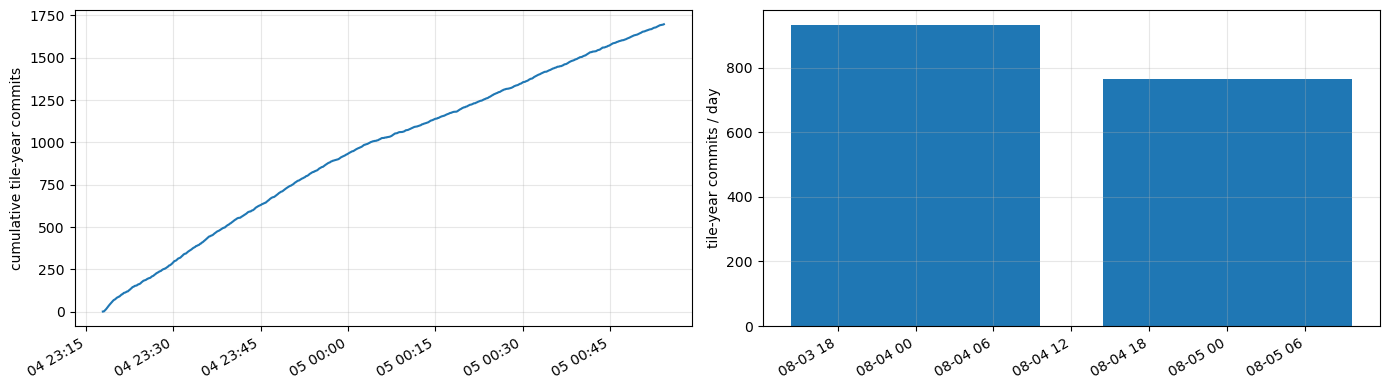

In [30]:
done_over_time = year_commits.sort_values('written_at')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(done_over_time.written_at, np.arange(1, len(done_over_time) + 1), lw=1.5)
axes[0].set_ylabel('cumulative tile-year commits')
per_day = done_over_time.set_index('written_at')['snapshot_id'].resample('1D').count()
axes[1].bar(per_day.index, per_day.values, color='tab:blue')
axes[1].set_ylabel('tile-year commits / day')
for ax in axes:
    ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()

In [31]:
window_h = 24
rate_per_h = (year_commits.written_at >= now - pd.Timedelta(hours=window_h)).sum() / window_h
n_remaining = n_eligible - n_done
print(f'throughput (last {window_h} h): {rate_per_h:.1f} tile-years/hour')
if rate_per_h > 0 and n_remaining > 0:
    print(f'{n_remaining:,} eligible tile-years remaining '
          f'-> ~{n_remaining / rate_per_h / 24:.1f} days at this rate')

throughput (last 24 h): 70.7 tile-years/hour
44,800 eligible tile-years remaining -> ~26.4 days at this rate


## Interactive map

The registry GeoDataFrame already carries the tile metadata (snow fraction, per-polarization
S1 item counts, probe dates, notes) and the derived status columns. Merge in per-tile
processing aggregates from the newest commit per (tile, water year), then `explore()`.
The tooltip shows the headline columns on hover; **click a tile for the full popup with every
column**.

In [32]:
newest_years = year_flat.drop_duplicates(subset=['row', 'col', 'water_year'], keep='first')

agg_spec = {
    'n_year_commits': ('snapshot_id', 'count'),
    'total_duration_min': ('duration_s', lambda s: round(float(s.sum()) / 60, 1)),
    'last_commit_at': ('written_at', 'max'),
    'n_thinned_years': ('missing_assets', lambda s: int(s.notna().sum())),
}
for name, column, how in [('total_valid_px', 'stats.valid_px', 'sum'),
                          ('max_scenes_per_year', 'stats.n_scenes', 'max'),
                          ('median_tr_days', 'stats.median_tr_days', 'median')]:
    if column in newest_years.columns:
        agg_spec[name] = (column, how)
if 'prov.platform' in newest_years.columns:
    agg_spec['platforms'] = ('prov.platform',
                             lambda s: ', '.join(sorted(s.dropna().unique())))

tile_agg = newest_years.groupby(['row', 'col']).agg(**agg_spec).reset_index()

map_gdf = tiles_gdf.merge(tile_agg, on=['row', 'col'], how='left')
if 'total_valid_px' in map_gdf.columns:
    map_gdf['total_valid_px'] = map_gdf['total_valid_px'].fillna(0).astype('int64')
# folium tooltips/popups can't serialize datetimes -- stringify them
for column in map_gdf.columns:
    if pd.api.types.is_datetime64_any_dtype(map_gdf[column]):
        map_gdf[column] = map_gdf[column].dt.strftime('%Y-%m-%d %H:%M').fillna('')
map_gdf.head(3)

,row,col,percent_valid_snow_pixels,n_vv_items,n_vh_items,n_hh_items,n_hv_items,n_items_total,first_vv_date,s1_probe_date,...,n_years_eligible,tile_status,n_year_commits,total_duration_min,last_commit_at,n_thinned_years,total_valid_px,max_scenes_per_year,median_tr_days,platforms
0,16,152,100.0,299,299,0,0,299,2015-04-24 00:00,2026-08-04 00:00,...,11,unprocessed,NaN,NaN,,NaN,0,NaN,NaN,NaN
1,16,45,100.0,1502,1448,0,0,1502,2015-03-14 00:00,2026-08-04 00:00,...,11,unprocessed,NaN,NaN,,NaN,0,NaN,NaN,NaN
2,15,70,100.0,370,370,3,3,373,2015-03-26 00:00,2026-08-04 00:00,...,11,unprocessed,NaN,NaN,,NaN,0,NaN,NaN,NaN


In [33]:
STATUS_COLORS = {'complete': '#2e7d32', 'partial': '#f9a825', 'unprocessed': '#c62828'}
present = [s for s in STATUS_COLORS if s in set(map_gdf.tile_status)]
tooltip_cols = [c for c in ['row', 'col', 'tile_status', 'composites', 'n_years_done',
                            'n_years_eligible', 'percent_valid_snow_pixels',
                            'total_duration_min', 'last_commit_at', 'platforms']
                if c in map_gdf.columns]

map_gdf.explore(
    column='tile_status',
    categorical=True,
    categories=present,
    cmap=[STATUS_COLORS[s] for s in present],
    tiles='Esri.WorldImagery',
    tooltip=tooltip_cols,
    popup=True,
    style_kwds={'fillOpacity': 0.6, 'weight': 0.4},
)

Same map for a single water year — set `wy_to_map` to any year in the config:

In [34]:
# wy_to_map = int(config.water_years[-1])

# WY_COLORS = {'data': '#2e7d32', 'empty': '#9e9e9e', 'missing': '#c62828',
#              'ineligible': '#64b5f6'}
# wy_column = f'wy_{wy_to_map}'
# present = [s for s in WY_COLORS if s in set(map_gdf[wy_column])]

# map_gdf.explore(
#     column=wy_column,
#     categorical=True,
#     categories=present,
#     cmap=[WY_COLORS[s] for s in present],
#     tiles='Esri.WorldImagery',
#     tooltip=['row', 'col', wy_column, 'hemisphere', 'tile_status', 'n_years_done'],
#     popup=True,
#     style_kwds={'fillOpacity': 0.6, 'weight': 0.4},
# )

## Remaining work

`status.get_remaining_work` is exactly what the dispatchers (`get_tiles_for_batch.py`,
`run_tiles.py`) consume: snowiest-first work items with each tile's missing water years. An
empty `water_years` list means only the composites need (re)computing.

In [35]:
work = status.get_remaining_work(config, repo=repo)
n_years_remaining = sum(len(item['water_years']) for item in work)
composites_only = sum(1 for item in work if not item['water_years'])
print(f'{len(work):,} tiles still need work: {n_years_remaining:,} tile-years to (re)process, '
      f'{composites_only:,} tiles need only a composites refresh')
work[:5]

4,090 tiles still need work: 44,800 tile-years to (re)process, 0 tiles need only a composites refresh


[{'row': 16,
  'col': 152,
  'water_years': [2015,
   2016,
   2017,
   2018,
   2019,
   2020,
   2021,
   2022,
   2023,
   2024,
   2025]},
 {'row': 16,
  'col': 45,
  'water_years': [2015,
   2016,
   2017,
   2018,
   2019,
   2020,
   2021,
   2022,
   2023,
   2024,
   2025]},
 {'row': 15,
  'col': 70,
  'water_years': [2015,
   2016,
   2017,
   2018,
   2019,
   2020,
   2021,
   2022,
   2023,
   2024,
   2025]},
 {'row': 15,
  'col': 71,
  'water_years': [2015,
   2016,
   2017,
   2018,
   2019,
   2020,
   2021,
   2022,
   2023,
   2024,
   2025]},
 {'row': 15,
  'col': 55,
  'water_years': [2015,
   2016,
   2017,
   2018,
   2019,
   2020,
   2021,
   2022,
   2023,
   2024,
   2025]}]

## Persist fleet diagnostics → results CSVs

Point-in-time snapshots of everything above that only existed as cell output — the
`_written_at` column records when each snapshot was taken (the fleet keeps moving):

- **`tile_status.csv`** — one row per registry tile (`to_process == True`): per-water-year
  status columns, `tile_status`, composite staleness, centroid lon/lat (geometry lives in the
  registry geojson), **plus per-tile processing stats** aggregated from the newest commit per
  (tile, water year): wall/core-hours, GB read at 80 m, valid pixels, scenes, throughput,
  peak RSS, dropped scenes, last-processed time, and `n_commits_all` vs `n_year_commits`
  (the gap = superseded reprocessing attempts). Commits from before 2026-08-04 predate the
  `dest_gb`/`cpu_count` metadata, so those aggregates can be partial per tile.
- **`wy_completion_breakdown.csv`** — data/empty/missing/ineligible counts + % done per water year.
- **`commit_outcome_summary.csv`** — per (status, empty_reason): commit counts, median/max
  durations, median valid px / scenes / orbits / temporal resolution.
- **`dropped_scenes.csv`** — the thinned-year scene list from above (one row per
  tile × water year × dropped scene id).
- **`remaining_work.csv`** — the dispatcher's view: missing water years per tile.


In [36]:
from global_snowmelt_runoff_onset.results import save_result_table

V = config.version

# --- per-tile processing stats from the commit history ---
# newest_per_year (dropped-scenes section) = the commits that produced the data
# currently in the store; year_flat additionally counts superseded attempts.
# _col (bulk-stats section) guards for stats columns absent on pre-2026-08-04 commits.
npy = newest_per_year
tile_key = [npy['row'], npy['col']]
per_tile = npy.groupby(['row', 'col']).agg(
    n_year_commits=('snapshot_id', 'count'),
    last_processed=('written_at', 'max'),
)
per_tile['wall_hours'] = (npy['duration_s'].groupby(tile_key).sum() / 3600).round(2)
per_tile['core_hours'] = ((npy['duration_s'] / 3600 * _col(npy, 'prov.cpu_count'))
                          .groupby(tile_key).sum().round(2))
for out, col, how in [('dest_gb_read', 'stats.dest_gb', 'sum'),
                      ('valid_px', 'stats.valid_px', 'sum'),
                      ('n_scenes', 'stats.n_scenes', 'sum'),
                      ('median_mb_s_effective', 'stats.mb_s_effective', 'median'),
                      ('max_peak_rss_gb', 'stats.peak_rss_gb', 'max')]:
    per_tile[out] = _col(npy, col).groupby(tile_key).agg(how).round(2)
per_tile['n_dropped_scenes'] = dropped_scenes.groupby(['row', 'col']).size()
per_tile['n_dropped_scenes'] = per_tile['n_dropped_scenes'].fillna(0).astype(int)
per_tile['n_commits_all'] = year_flat.groupby(['row', 'col']).size()  # incl. superseded
per_tile = per_tile.reset_index()

# centroids via a projected CRS (EPSG:6933 equal-area), back to lon/lat --
# .centroid directly on a geographic CRS is distorted (and warns)
tile_centroids = tiles_gdf.geometry.to_crs(epsg=6933).centroid.to_crs(epsg=4326)
tile_status_df = (
    tiles_gdf.drop(columns='geometry')
    .assign(centroid_lon=tile_centroids.x.round(4),
            centroid_lat=tile_centroids.y.round(4))
    .merge(per_tile, on=['row', 'col'], how='left')
)
save_result_table(tile_status_df, 'tile_status', version=V, results_dir='results')

save_result_table(wy_breakdown.rename_axis('water_year').reset_index(),
                  'wy_completion_breakdown', version=V, results_dir='results')

outcome_summary_df = (year_flat
                      .groupby(['status', 'empty_reason'], dropna=False)
                      .agg(**agg_spec)
                      .reset_index())
save_result_table(outcome_summary_df, 'commit_outcome_summary', version=V, results_dir='results')

save_result_table(dropped_scenes, 'dropped_scenes', version=V, results_dir='results')

remaining_work_df = pd.DataFrame([
    {'row': item['row'], 'col': item['col'],
     'n_missing_years': len(item['water_years']),
     'missing_water_years': ','.join(str(wy) for wy in item['water_years']),
     'composites_only': not item['water_years']}
    for item in work
])
save_result_table(remaining_work_df, 'remaining_work', version=V, results_dir='results')

wrote 4227 row(s) -> results/v10/tile_status.csv
wrote 11 row(s) -> results/v10/wy_completion_breakdown.csv
wrote 3 row(s) -> results/v10/commit_outcome_summary.csv
wrote 1 row(s) -> results/v10/dropped_scenes.csv
wrote 4090 row(s) -> results/v10/remaining_work.csv


PosixPath('results/v10/remaining_work.csv')